# 73 — Cross-run city-swap comparison (paper-facing)

**Companion to `71_unified_models_comparison.ipynb`:** this notebook focuses on **counterfactual city perturbations** (flip rates and swap-set metrics), using **only saved artifacts** — no re-eval, no retraining.

**Sources stitched together:**
- **70 batch:** `city_swap_all/city_swap_all_models.json` (main checkpoints)
- **C10 challengers:** `challengers_city_swap/c10_selected_family_city_swap_summary.csv`
- **72 restored:** `two-models-restore/city_swap_restored_models/72_restored_models_city_swap_summary.csv`
- *(Optional loose JSON)* any `city_swap_summary.json` under `notebooks/results/` not already represented (dedup by `model_name`)

**Outputs**

| Tables | `notebooks/results/cross_run_city_swap/` |
| Figures | `figures/cross_run_city_swap/` |

The same `73_*` filenames are **mirrored** under `notebooks/results/cross_run_city_swap_comparison/` for older links.


## What you can read off quickly

- **Most stable under city swap:** lowest `overall_flip_rate` (among rows with a swap eval).
- **Good robustness + quality:** low flip **and** `swap_macro_f1` near your acceptance threshold — see trade-off plots and `balance_robust_quality`.
- **Disagreement with fairness gaps:** a model can have a **low robust TPR gap** but **high flip** (or the reverse); **`delta_rank_flip_minus_gap_rank`** on the merged table makes mismatches visible.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    HAS_MPL = True
except ModuleNotFoundError:
    HAS_MPL = False
    plt = None
    mpatches = None

CWD = Path.cwd()
NOTEBOOK_DIR = CWD if CWD.name == "notebooks" else (CWD / "notebooks")
REPO_ROOT = NOTEBOOK_DIR.parent
NOTEBOOK_RESULTS_ROOT = REPO_ROOT / "notebooks" / "results"
LEGACY_RESULTS_ROOT = REPO_ROOT / "results"

RESULTS_DIR = NOTEBOOK_RESULTS_ROOT / "cross_run_city_swap"
LEGACY_RESULTS_DIR = NOTEBOOK_RESULTS_ROOT / "cross_run_city_swap_comparison"
FIGURES_DIR = REPO_ROOT / "figures" / "cross_run_city_swap"
LEGACY_FIGURES_DIR = REPO_ROOT / "figures" / "cross_run_city_swap_comparison"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LEGACY_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LEGACY_FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def resolve_results_path(*relative_parts: str) -> Path:
    candidates = [
        NOTEBOOK_RESULTS_ROOT.joinpath(*relative_parts),
        LEGACY_RESULTS_ROOT.joinpath(*relative_parts),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    fallback_name = relative_parts[-1]
    search_roots = [NOTEBOOK_RESULTS_ROOT, LEGACY_RESULTS_ROOT, REPO_ROOT]
    for root in search_roots:
        if not root.exists():
            continue
        matches = sorted(root.rglob(fallback_name))
        if matches:
            return matches[0]
    raise FileNotFoundError(
        f"Could not locate {fallback_name}. Checked direct candidates: {candidates}"
    )


MAIN_SWAP_JSON = resolve_results_path("city_swap_all", "city_swap_all_models.json")
UNIFIED_PRIMARY = NOTEBOOK_RESULTS_ROOT / "unified_comparison" / "01_unified_models_full_table.csv"
UNIFIED_FALLBACK = NOTEBOOK_RESULTS_ROOT / "unified_comparison" / "c71_unified_models_table.csv"
C10_SUMMARY_CSV = resolve_results_path("challengers_city_swap", "c10_selected_family_city_swap_summary.csv")
R72_SUMMARY_CSV = resolve_results_path(
    "two-models-restore", "city_swap_restored_models", "72_restored_models_city_swap_summary.csv"
)
UNIFIED_TABLE_CSV = UNIFIED_PRIMARY if UNIFIED_PRIMARY.exists() else resolve_results_path(
    "unified_comparison", "c71_unified_models_table.csv"
)
RANK71_CSV = NOTEBOOK_RESULTS_ROOT / "unified_comparison" / "04_ranking_picks_by_scope.csv"

manifest = {
    "main_swap_json": str(MAIN_SWAP_JSON.relative_to(REPO_ROOT)),
    "unified_table": str(Path(UNIFIED_TABLE_CSV).relative_to(REPO_ROOT)),
    "c10_summary": str(C10_SUMMARY_CSV.relative_to(REPO_ROOT)),
    "r72_summary": str(R72_SUMMARY_CSV.relative_to(REPO_ROOT)),
}

print("Repo root:", REPO_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("MAIN_SWAP_JSON:", MAIN_SWAP_JSON)
print("UNIFIED_TABLE:", UNIFIED_TABLE_CSV)


Repo root: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository
RESULTS_DIR: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/cross_run_city_swap
FIGURES_DIR: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/cross_run_city_swap
MAIN_SWAP_JSON: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/city_swap_all/city_swap_all_models.json
UNIFIED_TABLE: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/unified_comparison/01_unified_models_full_table.csv


In [2]:
unified = pd.read_csv(UNIFIED_TABLE_CSV)
unified = unified.rename(columns={"display_name": "display_name_c71"})

with MAIN_SWAP_JSON.open("r", encoding="utf-8") as f:
    main_swap_raw = json.load(f)

main_rows = []
for run_name, payload in main_swap_raw.items():
    row = {
        "source_run": "70_batch",
        "expected_track": "main",
        "run_name": run_name,
        "status": "error" if "error" in payload else "ok",
        "error": payload.get("error"),
        "model_dir": payload.get("model_dir"),
        "overall_flip_rate": payload.get("overall_flip_rate"),
        "swap_accuracy": payload.get("accuracy"),
        "swap_macro_f1": payload.get("macro_f1"),
        "uses_scrubbing": payload.get("uses_scrubbing"),
    }
    if row["model_dir"]:
        row["model_name"] = Path(row["model_dir"]).name
    else:
        row["model_name"] = run_name

    per_city = payload.get("per_city_flip_rate", {}) or {}
    per_class = payload.get("per_class_flip_rate", {}) or {}
    if per_city:
        city_rates = [v.get("flip_rate", v) if isinstance(v, dict) else v for v in per_city.values()]
        row["max_city_flip_rate"] = max(city_rates)
        row["min_city_flip_rate"] = min(city_rates)
    if per_class:
        class_rates = [v.get("flip_rate", v) if isinstance(v, dict) else v for v in per_class.values()]
        row["max_class_flip_rate"] = max(class_rates)
    main_rows.append(row)

main_df = pd.DataFrame(main_rows)

c10_df = pd.read_csv(C10_SUMMARY_CSV).rename(
    columns={
        "family": "family_from_swap",
        "accuracy": "swap_accuracy",
        "macro_f1": "swap_macro_f1",
    }
)
c10_df["source_run"] = "c10_challengers"
c10_df["expected_track"] = "challenger"
c10_df["run_name"] = c10_df["model_name"]
c10_df["status"] = c10_df["status"].fillna("ok")
city_flip_cols = [c for c in c10_df.columns if c.startswith("flip_")]
if city_flip_cols:
    c10_df["max_city_flip_rate"] = c10_df[city_flip_cols].max(axis=1)
    c10_df["min_city_flip_rate"] = c10_df[city_flip_cols].min(axis=1)

restored_df = pd.read_csv(R72_SUMMARY_CSV).rename(
    columns={
        "family": "family_from_swap",
        "accuracy": "swap_accuracy",
        "macro_f1": "swap_macro_f1",
    }
)
restored_df["source_run"] = "72_restored"
restored_df["expected_track"] = "main"
restored_df["run_name"] = restored_df["model_name"]

keep_cols = [
    "source_run",
    "run_name",
    "expected_track",
    "model_name",
    "family_from_swap",
    "status",
    "error",
    "swap_accuracy",
    "swap_macro_f1",
    "overall_flip_rate",
    "max_city_flip_rate",
    "min_city_flip_rate",
    "model_dir",
    "model_path",
    "uses_scrubbing",
]

main_df = main_df.reindex(columns=keep_cols)
c10_df = c10_df.reindex(columns=keep_cols)
restored_df = restored_df.reindex(columns=keep_cols)

swap_all = pd.concat([main_df, c10_df, restored_df], ignore_index=True, sort=False)

# Optional: append loose city_swap_summary.json rows under notebooks/results (dedup by model_name + source_run heuristic)
loose_rows = []
for js in sorted(NOTEBOOK_RESULTS_ROOT.rglob("city_swap_summary.json")):
    rel_parts = js.relative_to(NOTEBOOK_RESULTS_ROOT).parts
    if "city_swap_all" in rel_parts:
        continue
    try:
        payload = json.loads(js.read_text(encoding="utf-8"))
    except Exception:
        continue
    if not isinstance(payload, dict) or "error" in payload:
        continue
    md_ = payload.get("model_dir") or ""
    mname = Path(md_).name if md_ else js.parent.name
    src = "loose_json:" + "/".join(rel_parts[:-1])[:80]
    loose_rows.append(
        {
            "source_run": src,
            "run_name": mname,
            "expected_track": "challenger" if "challengers" in str(js) else "main",
            "model_name": mname,
            "family_from_swap": np.nan,
            "status": "ok",
            "error": np.nan,
            "swap_accuracy": payload.get("accuracy"),
            "swap_macro_f1": payload.get("macro_f1"),
            "overall_flip_rate": payload.get("overall_flip_rate"),
            "max_city_flip_rate": np.nan,
            "min_city_flip_rate": np.nan,
            "model_dir": md_,
            "model_path": np.nan,
            "uses_scrubbing": payload.get("uses_scrubbing"),
        }
    )

if loose_rows:
    loose_df = pd.DataFrame(loose_rows)
    loose_df = loose_df[~loose_df["model_name"].isin(swap_all["model_name"].values)]
    loose_df = loose_df.reindex(columns=keep_cols)
    if len(loose_df):
        swap_all = pd.concat([swap_all, loose_df], ignore_index=True, sort=False)

manifest["n_rows_after_loose_merge"] = int(len(swap_all))
swap_all


,source_run,run_name,expected_track,model_name,family_from_swap,status,error,swap_accuracy,swap_macro_f1,overall_flip_rate,max_city_flip_rate,min_city_flip_rate,model_dir,model_path,uses_scrubbing
0,70_batch,1_baseline,main,bert_9classes_final,NaN,ok,NaN,0.608530,0.620627,0.077132,0.045735,0.019964,bert_9classes_final,NaN,False
1,70_batch,2_groupdro,main,bert_gdro_eta01_2ep,NaN,ok,NaN,0.547731,0.552506,0.115789,0.072958,0.026316,bert_gdro_eta01_2ep,NaN,False
2,70_batch,3_scrubbing,main,bert_scrubbing,NaN,ok,NaN,0.594192,0.610640,0.000000,0.000000,0.000000,bert_scrubbing,NaN,True
3,70_batch,4_oversampling,main,bert_oversample_only,NaN,ok,NaN,0.600544,0.611463,0.100363,0.063339,0.025953,bert_oversample_only,NaN,False
4,70_batch,5_focal_loss,main,bert_focal_loss,NaN,ok,NaN,0.592559,0.613432,0.068966,0.041742,0.019238,bert_focal_loss,NaN,False
5,70_batch,6_adversarial,main,6_adversarial,NaN,error,failed to load,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
6,70_batch,7_label_smoothing,main,bert_label_smoothing,NaN,ok,NaN,0.596189,0.608055,0.107260,0.080218,0.020871,bert_label_smoothing,NaN,False
7,70_batch,8_attribution_reg,main,8_attribution_reg,NaN,error,failed to load,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
8,70_batch,9_combined_scrub_gdro,main,bert_debiased_combo,NaN,ok,NaN,0.486570,0.475259,0.000000,0.000000,0.000000,bert_debiased_combo,NaN,True
9,70_batch,10_combined_best,main,combined_scrubbing_groupdro,NaN,ok,NaN,0.576407,0.597117,0.000000,0.000000,0.000000,combined_scrubbing_groupdro,NaN,True


In [3]:
compare_df = swap_all.merge(
    unified[
        [
            "track",
            "family_group",
            "model_name",
            "display_name_c71",
            "method",
            "accuracy",
            "macro_f1",
            "worst_gap",
            "macro_gap",
        ]
    ],
    left_on=["model_name", "expected_track"],
    right_on=["model_name", "track"],
    how="left",
)

compare_df["family"] = compare_df["family_from_swap"].fillna(compare_df["family_group"])
compare_df["display_name"] = compare_df["display_name_c71"].fillna(compare_df["model_name"])

compare_df["delta_swap_f1_minus_standard"] = pd.to_numeric(compare_df["swap_macro_f1"], errors="coerce") - pd.to_numeric(
    compare_df["macro_f1"], errors="coerce"
)
compare_df["delta_swap_acc_minus_standard"] = pd.to_numeric(compare_df["swap_accuracy"], errors="coerce") - pd.to_numeric(
    compare_df["accuracy"], errors="coerce"
)

ok_mask = compare_df["status"] == "ok"
ok_df = compare_df.loc[ok_mask].copy()

# Proper ranks (1 = best), only among OK rows; NaN for failed
compare_df["rank_flip_then_swap_f1"] = np.nan
compare_df["rank_fairest_gap_then_f1"] = np.nan
compare_df["rank_standard_macro_f1"] = np.nan

if not ok_df.empty:
    r1 = ok_df.sort_values(["overall_flip_rate", "swap_macro_f1"], ascending=[True, False], na_position="last")
    compare_df.loc[r1.index, "rank_flip_then_swap_f1"] = np.arange(1, len(r1) + 1)

    sub_gap = ok_df.dropna(subset=["worst_gap"])
    if not sub_gap.empty:
        r2 = sub_gap.sort_values(["worst_gap", "macro_f1"], ascending=[True, False], na_position="last")
        compare_df.loc[r2.index, "rank_fairest_gap_then_f1"] = np.arange(1, len(r2) + 1)

    sub_f1 = ok_df.dropna(subset=["macro_f1"])
    if not sub_f1.empty:
        r3 = sub_f1.sort_values(["macro_f1", "overall_flip_rate"], ascending=[False, True], na_position="last")
        compare_df.loc[r3.index, "rank_standard_macro_f1"] = np.arange(1, len(r3) + 1)

    both = compare_df.loc[ok_mask, ["rank_flip_then_swap_f1", "rank_fairest_gap_then_f1"]].dropna()
    if len(both):
        compare_df["delta_rank_flip_minus_gap_rank"] = compare_df["rank_flip_then_swap_f1"] - compare_df[
            "rank_fairest_gap_then_f1"
        ]

# Balance score: min-max among OK rows with flip + swap F1
compare_df["balance_robust_quality"] = np.nan
sub_b = ok_df.dropna(subset=["overall_flip_rate", "swap_macro_f1"])
if len(sub_b) > 1:
    fl = sub_b["overall_flip_rate"]
    f1 = sub_b["swap_macro_f1"]
    fn = (f1 - f1.min()) / (f1.max() - f1.min() + 1e-12)
    pn = 1 - (fl - fl.min()) / (fl.max() - fl.min() + 1e-12)
    compare_df.loc[sub_b.index, "balance_robust_quality"] = (fn + pn) / 2

out_cols = [
    "rank_flip_then_swap_f1",
    "rank_fairest_gap_then_f1",
    "rank_standard_macro_f1",
    "delta_rank_flip_minus_gap_rank",
    "source_run",
    "track",
    "family",
    "model_name",
    "display_name",
    "status",
    "accuracy",
    "macro_f1",
    "worst_gap",
    "macro_gap",
    "swap_accuracy",
    "swap_macro_f1",
    "delta_swap_f1_minus_standard",
    "delta_swap_acc_minus_standard",
    "overall_flip_rate",
    "max_city_flip_rate",
    "min_city_flip_rate",
    "balance_robust_quality",
    "uses_scrubbing",
    "error",
]

compare_df = compare_df.sort_values(
    ["status", "overall_flip_rate", "swap_macro_f1"], ascending=[True, True, False], na_position="last"
)

front = [c for c in out_cols if c in compare_df.columns]
rest = [c for c in compare_df.columns if c not in front]
compare_df = compare_df[front + rest]

compare_df.to_csv(RESULTS_DIR / "01_cross_run_city_swap_master.csv", index=False)
compare_df.to_csv(LEGACY_RESULTS_DIR / "73_cross_run_city_swap_table.csv", index=False)
compare_df


,rank_flip_then_swap_f1,rank_fairest_gap_then_f1,rank_standard_macro_f1,delta_rank_flip_minus_gap_rank,source_run,track,family,model_name,display_name,status,...,uses_scrubbing,error,run_name,expected_track,family_from_swap,model_dir,model_path,family_group,display_name_c71,method
5,NaN,NaN,NaN,NaN,70_batch,NaN,NaN,6_adversarial,6_adversarial,error,...,None,failed to load,6_adversarial,main,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,70_batch,NaN,NaN,8_attribution_reg,8_attribution_reg,error,...,None,failed to load,8_attribution_reg,main,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,3.0,8.0,-2.0,70_batch,main,scrubbing,bert_scrubbing,Data Scrubbing,ok,...,True,NaN,3_scrubbing,main,NaN,bert_scrubbing,NaN,scrubbing,Data Scrubbing,Data Scrubbing + sqrt_rw
9,2.0,NaN,10.0,NaN,70_batch,main,combined,combined_scrubbing_groupdro,Combined Best,ok,...,True,NaN,10_combined_best,main,NaN,combined_scrubbing_groupdro,NaN,combined,Combined Best,Combined Best
8,3.0,12.0,13.0,-9.0,70_batch,main,combined,bert_debiased_combo,Combined Scrub + GroupDRO,ok,...,True,NaN,9_combined_scrub_gdro,main,NaN,bert_debiased_combo,NaN,combined,Combined Scrub + GroupDRO,sqrt_reweight + oversampling + GroupDRO
12,4.0,11.0,3.0,-7.0,c10_challengers,challenger,class_balanced,class_balanced_cbce_beta099_2ep,class_balanced_cbce_beta099_2ep,ok,...,NaN,NaN,class_balanced_cbce_beta099_2ep,challenger,class_balanced,NaN,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,class_balanced,class_balanced_cbce_beta099_2ep,Class-Balanced CE + sqrt_rw
15,5.0,NaN,NaN,NaN,72_restored,NaN,adversarial,restored_adversarial,restored_adversarial,ok,...,NaN,NaN,restored_adversarial,main,adversarial,NaN,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,NaN,NaN,NaN
11,6.0,4.0,4.0,2.0,c10_challengers,challenger,rdrop,rdrop_alpha10_2ep,rdrop_alpha10_2ep,ok,...,NaN,NaN,rdrop_alpha10_2ep,challenger,rdrop,NaN,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,rdrop,rdrop_alpha10_2ep,R-Drop + sqrt_rw
16,7.0,NaN,NaN,NaN,72_restored,NaN,attr_reg,restored_attr_reg,restored_attr_reg,ok,...,NaN,NaN,restored_attr_reg,main,attr_reg,NaN,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,NaN,NaN,NaN
4,8.0,8.0,6.0,0.0,70_batch,main,focal,bert_focal_loss,Focal Loss,ok,...,False,NaN,5_focal_loss,main,NaN,bert_focal_loss,NaN,focal,Focal Loss,Focal Loss gamma=2.0 + sqrt_rw


In [4]:
ok_df = compare_df[compare_df["status"] == "ok"].copy()

summary = {
    "n_total_rows": int(len(compare_df)),
    "n_ok_rows": int((compare_df["status"] == "ok").sum()),
    "n_failed_rows": int((compare_df["status"] != "ok").sum()),
}

if not ok_df.empty:
    best_flip = ok_df.sort_values(["overall_flip_rate", "swap_macro_f1"], ascending=[True, False], na_position="last").iloc[0]
    best_macro_f1 = ok_df.sort_values(["swap_macro_f1", "overall_flip_rate"], ascending=[False, True], na_position="last").iloc[0]
    best_bal = ok_df.dropna(subset=["balance_robust_quality"])
    summary["best_city_swap_stability"] = {
        "model_name": best_flip["model_name"],
        "source_run": best_flip["source_run"],
        "overall_flip_rate": None if pd.isna(best_flip["overall_flip_rate"]) else float(best_flip["overall_flip_rate"]),
        "swap_macro_f1": None if pd.isna(best_flip["swap_macro_f1"]) else float(best_flip["swap_macro_f1"]),
    }
    summary["best_swap_macro_f1"] = {
        "model_name": best_macro_f1["model_name"],
        "source_run": best_macro_f1["source_run"],
        "overall_flip_rate": None if pd.isna(best_macro_f1["overall_flip_rate"]) else float(best_macro_f1["overall_flip_rate"]),
        "swap_macro_f1": None if pd.isna(best_macro_f1["swap_macro_f1"]) else float(best_macro_f1["swap_macro_f1"]),
    }
    if not best_bal.empty:
        br = best_bal.sort_values("balance_robust_quality", ascending=False).iloc[0]
        summary["best_flip_f1_balance"] = {
            "model_name": br["model_name"],
            "source_run": br["source_run"],
            "balance_robust_quality": float(br["balance_robust_quality"]),
            "overall_flip_rate": float(br["overall_flip_rate"]),
            "swap_macro_f1": float(br["swap_macro_f1"]),
        }

by_source = (
    compare_df.groupby("source_run", dropna=False)
    .agg(
        rows=("model_name", "size"),
        ok_rows=("status", lambda s: int((s == "ok").sum())),
        median_flip=("overall_flip_rate", "median"),
        best_flip=("overall_flip_rate", "min"),
        best_swap_f1=("swap_macro_f1", "max"),
    )
    .reset_index()
)
by_source.to_csv(RESULTS_DIR / "02_cross_run_city_swap_by_source.csv", index=False)
by_source.to_csv(LEGACY_RESULTS_DIR / "73_cross_run_city_swap_by_source.csv", index=False)

fam_g = (
    ok_df.groupby("family", dropna=False)
    .agg(
        n=("model_name", "count"),
        best_flip=("overall_flip_rate", "min"),
        median_flip=("overall_flip_rate", "median"),
        best_swap_f1=("swap_macro_f1", "max"),
        median_standard_f1=("macro_f1", "median"),
        median_gap=("worst_gap", "median"),
    )
    .reset_index()
)
fam_g.to_csv(RESULTS_DIR / "03_cross_run_city_swap_family_summary.csv", index=False)

rank_picks = []
if not ok_df.empty:
    for label, ascending, col in [
        ("lowest_flip", True, "overall_flip_rate"),
        ("highest_swap_f1", False, "swap_macro_f1"),
        ("best_balance", False, "balance_robust_quality"),
    ]:
        sub = ok_df.dropna(subset=[col]) if col in ok_df.columns else ok_df
        if sub.empty:
            continue
        r = sub.sort_values(col, ascending=ascending, na_position="last").iloc[0]
        rank_picks.append(
            {
                "criterion": label,
                "model_name": r["model_name"],
                "display_name": r["display_name"],
                "source_run": r["source_run"],
                "overall_flip_rate": r["overall_flip_rate"],
                "swap_macro_f1": r["swap_macro_f1"],
                "macro_f1": r["macro_f1"],
                "worst_gap": r["worst_gap"],
                "balance_robust_quality": r.get("balance_robust_quality"),
            }
        )
pd.DataFrame(rank_picks).to_csv(RESULTS_DIR / "04_city_swap_ranking_picks.csv", index=False)

disagree = ok_df.dropna(subset=["delta_rank_flip_minus_gap_rank"]).copy()
if not disagree.empty:
    disagree["abs_rank_mismatch"] = disagree["delta_rank_flip_minus_gap_rank"].abs()
    disagree.sort_values("abs_rank_mismatch", ascending=False)[
        [
            "model_name",
            "display_name",
            "source_run",
            "rank_flip_then_swap_f1",
            "rank_fairest_gap_then_f1",
            "delta_rank_flip_minus_gap_rank",
            "overall_flip_rate",
            "worst_gap",
            "macro_f1",
            "swap_macro_f1",
        ]
    ].to_csv(RESULTS_DIR / "05_rank_disagreement_flip_vs_gap.csv", index=False)

report_lines = [
    "=== 73 cross-run city-swap comparison (paper bundle) ===",
    f"rows_total: {summary['n_total_rows']}",
    f"rows_ok: {summary['n_ok_rows']}",
    f"rows_failed: {summary['n_failed_rows']}",
    "",
]
for key in ["best_city_swap_stability", "best_swap_macro_f1", "best_flip_f1_balance"]:
    if key not in summary:
        continue
    report_lines.append(f"{key}:")
    for k, v in summary[key].items():
        report_lines.append(f"  {k}: {v}")
    report_lines.append("")

if RANK71_CSV.exists():
    report_lines.append("--- Reference: 71 unified picks (most_robust_city_swap_flip) ---")
    r71 = pd.read_csv(RANK71_CSV)
    sub = r71[r71["criterion"] == "most_robust_city_swap_flip"]
    for _, row in sub.iterrows():
        report_lines.append(
            f"  [{row['scope']}] {row['display_name']} | flip={row.get('overall_flip_rate')} | f1={row.get('macro_f1')}"
        )
    report_lines.append("")

failed = compare_df[compare_df["status"] != "ok"][["model_name", "source_run", "status", "error"]]
if not failed.empty:
    report_lines.append("failed_rows:")
    for _, row in failed.iterrows():
        report_lines.append(
            f"  - {row['model_name']} | source={row['source_run']} | status={row['status']} | error={row['error']}"
        )

report_text = "\n".join(report_lines)
print(report_text)
(RESULTS_DIR / "06_cross_run_city_swap_report.txt").write_text(report_text, encoding="utf-8")
(LEGACY_RESULTS_DIR / "73_cross_run_city_swap_report.txt").write_text(report_text, encoding="utf-8")
(RESULTS_DIR / "07_cross_run_city_swap_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
(LEGACY_RESULTS_DIR / "73_cross_run_city_swap_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
manifest_serializable = {k: str(v) for k, v in manifest.items()}
manifest_serializable["outputs"] = [x.name for x in sorted(RESULTS_DIR.glob("*"))]
(RESULTS_DIR / "manifest.json").write_text(json.dumps(manifest_serializable, indent=2, ensure_ascii=False), encoding="utf-8")
by_source


=== 73 cross-run city-swap comparison (paper bundle) ===
rows_total: 17
rows_ok: 15
rows_failed: 2

best_city_swap_stability:
  model_name: bert_scrubbing
  source_run: 70_batch
  overall_flip_rate: 0.0
  swap_macro_f1: 0.6106395818352593

best_swap_macro_f1:
  model_name: label_smoothing_eps01_2ep
  source_run: c10_challengers
  overall_flip_rate: 0.0891107078039927
  swap_macro_f1: 0.6229579754516105

best_flip_f1_balance:
  model_name: bert_scrubbing
  source_run: 70_batch
  balance_robust_quality: 0.9582990929839278
  overall_flip_rate: 0.0
  swap_macro_f1: 0.6106395818352593

--- Reference: 71 unified picks (most_robust_city_swap_flip) ---
  [all_models] Data Scrubbing | flip=0.0 | f1=0.6105665172611873
  [main_track_only] Data Scrubbing | flip=0.0 | f1=0.6105665172611873

failed_rows:
  - 6_adversarial | source=70_batch | status=error | error=failed to load
  - 8_attribution_reg | source=70_batch | status=error | error=failed to load


,source_run,rows,ok_rows,median_flip,best_flip,best_swap_f1
0,70_batch,10,8,0.073049,0.000000,0.620627
1,72_restored,2,2,0.062523,0.061887,0.601165
2,c10_challengers,5,5,0.086751,0.057713,0.622958


In [5]:
leaderboard_cols = [
    "source_run",
    "family",
    "model_name",
    "display_name",
    "status",
    "rank_flip_then_swap_f1",
    "rank_fairest_gap_then_f1",
    "accuracy",
    "macro_f1",
    "swap_accuracy",
    "swap_macro_f1",
    "delta_swap_f1_minus_standard",
    "overall_flip_rate",
    "worst_gap",
    "macro_gap",
    "balance_robust_quality",
]
leaderboard = compare_df[[c for c in leaderboard_cols if c in compare_df.columns]].copy()
leaderboard.to_csv(RESULTS_DIR / "08_city_swap_leaderboard_compact.csv", index=False)
leaderboard


,source_run,family,model_name,display_name,status,rank_flip_then_swap_f1,rank_fairest_gap_then_f1,accuracy,macro_f1,swap_accuracy,swap_macro_f1,delta_swap_f1_minus_standard,overall_flip_rate,worst_gap,macro_gap,balance_robust_quality
5,70_batch,NaN,6_adversarial,6_adversarial,error,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,70_batch,NaN,8_attribution_reg,8_attribution_reg,error,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,70_batch,scrubbing,bert_scrubbing,Data Scrubbing,ok,1.0,3.0,0.594192,0.610567,0.594192,0.610640,0.000073,0.000000,0.300000,0.112077,0.958299
9,70_batch,combined,combined_scrubbing_groupdro,Combined Best,ok,2.0,NaN,0.576407,0.597117,0.576407,0.597117,0.000000,0.000000,NaN,NaN,0.912523
8,70_batch,combined,bert_debiased_combo,Combined Scrub + GroupDRO,ok,3.0,12.0,0.488203,0.480776,0.486570,0.475259,-0.005517,0.000000,0.405882,0.137764,0.500000
12,c10_challengers,class_balanced,class_balanced_cbce_beta099_2ep,class_balanced_cbce_beta099_2ep,ok,4.0,11.0,0.606897,0.620787,0.606897,0.620787,0.000000,0.057713,0.388235,0.137249,0.743434
15,72_restored,adversarial,restored_adversarial,restored_adversarial,ok,5.0,NaN,NaN,NaN,0.574410,0.594231,NaN,0.061887,NaN,NaN,0.635512
11,c10_challengers,rdrop,rdrop_alpha10_2ep,rdrop_alpha10_2ep,ok,6.0,4.0,0.606715,0.620074,0.606715,0.620074,0.000000,0.062069,0.311765,0.126811,0.722211
16,72_restored,attr_reg,restored_attr_reg,restored_attr_reg,ok,7.0,NaN,NaN,NaN,0.583303,0.601165,NaN,0.063158,NaN,NaN,0.653497
4,70_batch,focal,bert_focal_loss,Focal Loss,ok,8.0,8.0,0.592559,0.613432,0.592559,0.613432,0.000000,0.068966,0.329412,0.135682,0.669946


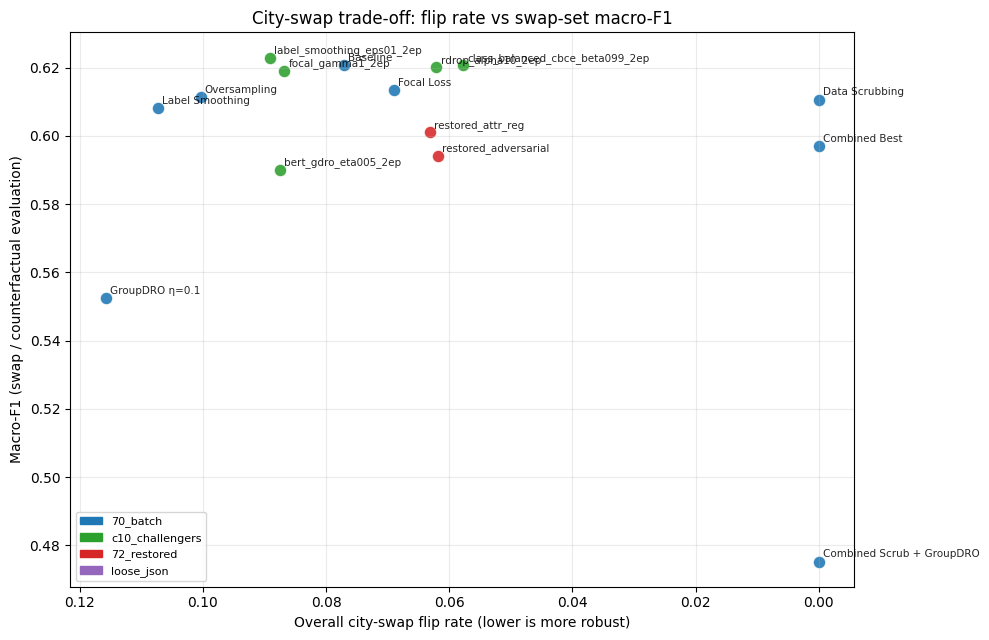

Saved /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/cross_run_city_swap/fig01_flip_vs_swap_macro_f1.png


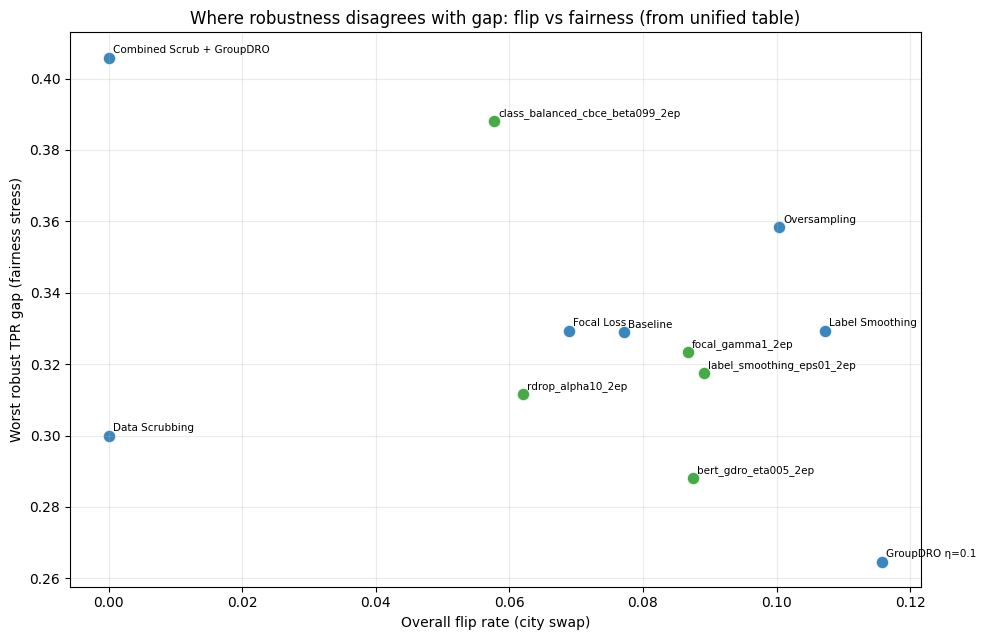

Saved /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/cross_run_city_swap/fig02_flip_vs_worst_gap.png


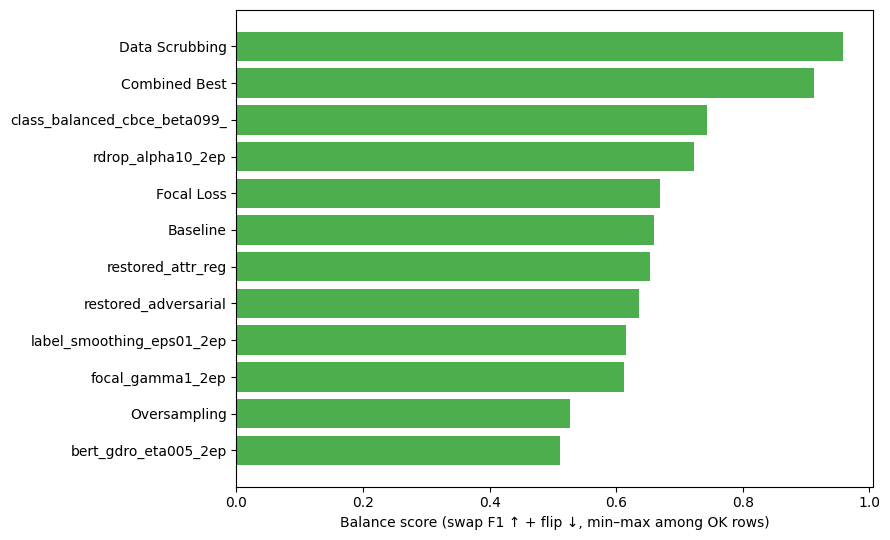

Saved /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/cross_run_city_swap/fig03_top_balance_scores.png


In [6]:
if not HAS_MPL:
    print("matplotlib not installed; skipping plots")
else:
    colors = {"70_batch": "#1f77b4", "c10_challengers": "#2ca02c", "72_restored": "#d62728"}

    def _source_color(sr):
        if sr in colors:
            return colors[sr]
        if isinstance(sr, str) and sr.startswith("loose_json"):
            return "#9467bd"
        return "#7f7f7f"

    plot_df = compare_df[compare_df["status"] == "ok"].dropna(subset=["overall_flip_rate", "swap_macro_f1"]).copy()

    fig, ax = plt.subplots(figsize=(10, 6.5))
    for _, row in plot_df.iterrows():
        ax.scatter(
            row["overall_flip_rate"],
            row["swap_macro_f1"],
            s=85,
            color=_source_color(row["source_run"]),
            alpha=0.88,
            edgecolors="white",
            linewidths=1.0,
        )
        lab = str(row["display_name"])[:34]
        ax.annotate(lab, (row["overall_flip_rate"], row["swap_macro_f1"]), fontsize=7.5, alpha=0.85, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel("Overall city-swap flip rate (lower is more robust)")
    ax.set_ylabel("Macro-F1 (swap / counterfactual evaluation)")
    ax.set_title("City-swap trade-off: flip rate vs swap-set macro-F1")
    ax.grid(alpha=0.25)
    ax.invert_xaxis()
    handles = [mpatches.Patch(color=c, label=k) for k, c in colors.items()]
    handles.append(mpatches.Patch(color="#9467bd", label="loose_json"))
    ax.legend(handles=handles, loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "fig01_flip_vs_swap_macro_f1.png", dpi=180, bbox_inches="tight")
    leg = LEGACY_FIGURES_DIR
    fig.savefig(leg / "73_cross_run_city_swap_scatter.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved", FIGURES_DIR / "fig01_flip_vs_swap_macro_f1.png")

    gap_df = plot_df.dropna(subset=["worst_gap"])
    if not gap_df.empty:
        fig2, ax2 = plt.subplots(figsize=(10, 6.5))
        for _, row in gap_df.iterrows():
            ax2.scatter(
                row["overall_flip_rate"],
                row["worst_gap"],
                s=85,
                color=_source_color(row["source_run"]),
                alpha=0.88,
                edgecolors="white",
                linewidths=1.0,
            )
            ax2.annotate(
                str(row["display_name"])[:32],
                (row["overall_flip_rate"], row["worst_gap"]),
                fontsize=7.5,
                xytext=(3, 3),
                textcoords="offset points",
            )
        ax2.set_xlabel("Overall flip rate (city swap)")
        ax2.set_ylabel("Worst robust TPR gap (fairness stress)")
        ax2.set_title("Where robustness disagrees with gap: flip vs fairness (from unified table)")
        ax2.grid(alpha=0.25)
        fig2.tight_layout()
        fig2.savefig(FIGURES_DIR / "fig02_flip_vs_worst_gap.png", dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved", FIGURES_DIR / "fig02_flip_vs_worst_gap.png")

    bdf = plot_df.dropna(subset=["balance_robust_quality"])
    if len(bdf) > 2:
        fig3, ax3 = plt.subplots(figsize=(9, 5.5))
        top = bdf.sort_values("balance_robust_quality", ascending=False).head(12)
        ax3.barh(top["display_name"].astype(str).str.slice(0, 28), top["balance_robust_quality"], color="#2ca02c", alpha=0.85)
        ax3.invert_yaxis()
        ax3.set_xlabel("Balance score (swap F1 ↑ + flip ↓, min–max among OK rows)")
        fig3.tight_layout()
        fig3.savefig(FIGURES_DIR / "fig03_top_balance_scores.png", dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved", FIGURES_DIR / "fig03_top_balance_scores.png")


## Key takeaways (paper)

- **Most stable under city perturbations** are rows with **lowest `overall_flip_rate`** on the saved protocol (70 + C10 + restored). The compact leaderboard is `08_city_swap_leaderboard_compact.csv`; picks are in `04_city_swap_ranking_picks.csv`.
- **Flip vs quality:** `fig01` shows whether a model keeps **swap-set macro-F1** while staying insensitive to city edits. **`balance_robust_quality`** (`03`/`master` table) is a simple **equal-weight** blend for a one-line ranking — tune weights in prose if needed.
- **Beyond standard fairness metrics:** `fig02` and `05_rank_disagreement_flip_vs_gap.csv` highlight cases where **robust TPR gap** (from unified / training snapshots) **ranks differently** from **city-swap flip** — meaning **slice-fairness** and **counterfactual location stability** are related but **not redundant**; city-swap stress-tests **rewritable surface cues** that gaps alone may not expose. Use **`delta_rank_flip_minus_gap_rank`** on the master table to spot large mismatches quickly.
- **Companion to 71:** Cross-check `04_ranking_picks_by_scope.csv` in unified comparison for labels like `most_robust_city_swap_flip`; numbers should align for models that appear in **`city_swap_all_models.json`**; challengers and restored runs **only appear here** in 73.

_Re-run this notebook after new city-swap JSON/CSV land in `notebooks/results/`; it does not call evaluation code._
